# ER1: No-Communication Control

Multi-agent coordination emerges from two sources: **what agents learn** and **what agents share**.
Before measuring the value of communication, we need to isolate the first factor — how well can agents learn to coordinate through observation alone?

This notebook trains agents on the Discovery K-N convergence task with **zero communication channels**.
The result is a performance floor: any communication protocol (ER2–E1) that fails to beat this floor adds complexity without benefit.

> **Research question:** Under partial observability and no message passing, how much of the rendezvous task can MARL policies solve through individual learning alone?

In [ ]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent.parent.parent
RENDEZVOUS_ROOT = REPO_ROOT / "rendezvous_comm"
sys.path.insert(0, str(RENDEZVOUS_ROOT))

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from src.config import load_experiment, find_configs
from src.storage import ExperimentStorage
from src.runner import run_sweep, evaluate_with_vmas, make_heuristic_policy_fn
from src.display import (
    display_config, display_metrics, display_sweep_summary, display_run_status,
    display_environment_info, scrollable_md, display_metric_cards, display_verdict,
    display_config_selector,
    display_baseline_comparison, display_results_dashboard,
    display_training_videos, display_artifact_tree,
)
from src.plotting import (
    plot_sweep_heatmap, plot_seed_variance, plot_training_dashboard,
    plot_baseline_grouped_bars, plot_results_comparison, save_figure,
)

print(f"Torch: {torch.__version__}  |  CUDA: {torch.cuda.is_available()}")

Torch: 2.10.0  |  CUDA: False


In [3]:
# ── Available configs with freshness status ──
display_config_selector("er1")

#,Config,Algo,N agents,LiDAR,Runs,Complete,Freshness
1,single_mappo_n4_l035.yaml,MAPPO,4,0.35,1,1/1,VALID
2,sweep_mappo-ippo_n2-6_l025-045.yaml,"MAPPO, IPPO",2-6,0.25-0.45,120,1/120,CONFIG CHANGED


## Configuration

Select a config from the dropdown above. Each YAML is self-contained — filename encodes what's inside:
- `single_*` → 1 run for quick validation (~15 min on CPU)
- `sweep_*` → full parameter sweep (hours/days)

Freshness badges: **VALID** = results match current config+code, **CONFIG/CODE CHANGED** = results are stale, **NEW** = no results yet.

The cell below loads the selected config and displays environment dimensions.

In [ ]:
# ── Select config here ──
# Pick from the table above. Change the filename to switch configs.
#CONFIG_FILE_NAME = "single_mappo_n4_l035.yaml"
CONFIG_FILE_NAME = "sweep_mappo-ippo_n2-6_l025-045.yaml"

CONFIG = RENDEZVOUS_ROOT / "configs" / "er1" / CONFIG_FILE_NAME
FORCE_RETRAIN = False  # Set True to re-run even if results exist

spec = load_experiment(CONFIG)
spec.ensure_dirs()

display_environment_info(spec)

In [5]:
display_config(spec)

## Measurement Strategy

We evaluate along three axes relevant to the no-comm baseline:

| Category | Metric | What it tells us |
|----------|--------|-----------------|
| **Task performance** | M1 Success Rate | Did agents cover *all* targets? |
| | M2 Avg Return | Net reward (covering − collisions − time) |
| | M3 Avg Steps | Speed of completion (200 = never finished) |
| | M6 Coverage Progress | Partial credit: fraction of targets covered |
| **Safety** | M4 Collisions/Episode | Spatial awareness between agents |
| **Coordination** | M8 Agent Utilization | Workload balance (CV, 0 = perfectly balanced) |
| | M9 Spatial Spread | Mean pairwise distance (higher = exploring) |

**M5 (Tokens)** is always 0 here — it becomes meaningful in ER2+.
**M7 (Sample Efficiency)** is computed post-training from BenchMARL curves.

### Reference baselines
Before training, we measure two non-learned policies to calibrate expectations:

ID,Metric,Heuristic,Random
M1,Success Rate,11.0%,0.0%
M6,Coverage Progress,63.3%,2.4%
M2,Avg Return,-10.42,-7.86
M3,Avg Steps,191.8,200.0
M4,Collisions/Episode,104.81,1.91
M9,Spatial Spread,0.681,1.080

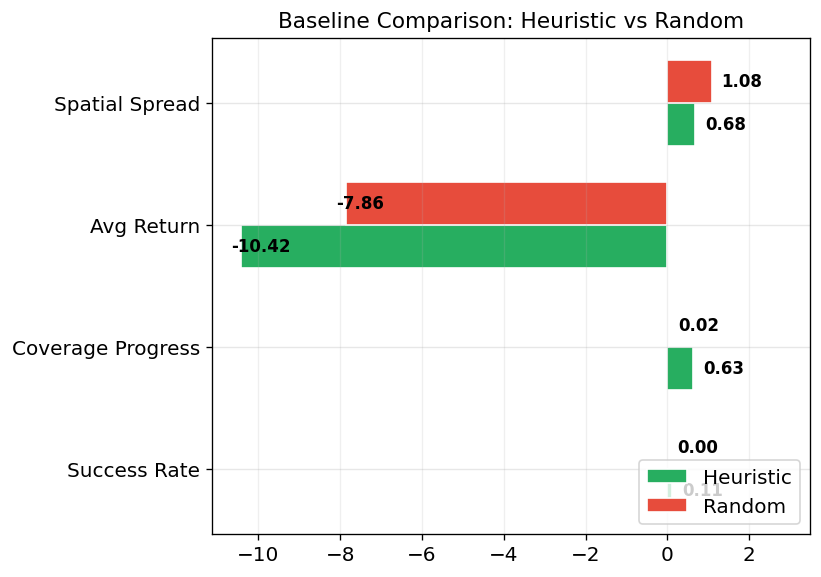

In [6]:
SANITY_OVERRIDES = {
    "n_agents": 4, "n_targets": 7, "agents_per_target": 2,
    "targets_respawn": False,
}

heuristic_fn = make_heuristic_policy_fn()
heuristic_metrics = evaluate_with_vmas(
    spec.task, task_overrides=SANITY_OVERRIDES,
    policy_fn=heuristic_fn, n_eval_episodes=200, n_envs=200,
)

random_metrics = evaluate_with_vmas(
    spec.task, task_overrides=SANITY_OVERRIDES,
    policy_fn=None, n_eval_episodes=200, n_envs=200,
)

# Grouped bar chart + comparison table side-by-side
fig = plot_baseline_grouped_bars(heuristic_metrics, random_metrics)
display_baseline_comparison(heuristic_metrics, random_metrics, fig=fig)

## Training

Each run: freeze config → train with BenchMARL (MAPPO/IPPO) → save policy → evaluate → save metrics + report.
Set `skip_complete=True` to resume interrupted sweeps without re-running finished runs.

In [7]:
display_run_status(spec)
results = run_sweep(spec, skip_complete=not FORCE_RETRAIN)

2026-03-09 19:32:35 INFO     SKIP  er1_mappo_n4_t7_k2_l035_s0 — already complete


## Training Curves

BenchMARL logs scalar metrics at each iteration. The dashboard below shows four key signals:
- **Eval Reward** — are agents improving?
- **Targets Covered** — are they learning the actual objective?
- **Covering Reward** — reward component from covering targets
- **Policy Entropy** — exploration level (should decrease but not collapse)

Saved: /Users/afin/Documents/Studio/PHD/Code/VectorizedMultiAgentSimulator/rendezvous_comm/results/er1/20260309_1608__er1_mappo_n4_t7_k2_l035_s0/output/training_dashboard.png


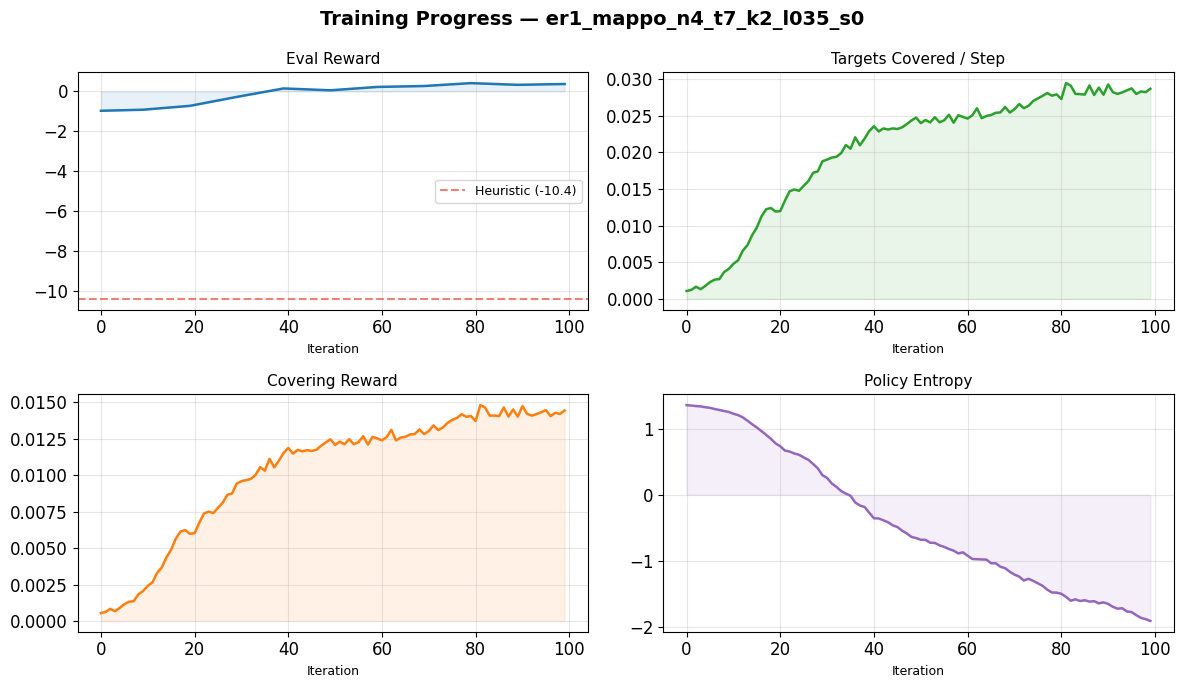

In [8]:
storage = ExperimentStorage("er1")
all_metrics = storage.load_all_metrics()

if not all_metrics:
    print("No completed runs yet. Run the training cell first.")
else:
    latest_run_id = sorted(all_metrics.keys())[-1]
    run_storage = storage.get_run(latest_run_id)
    scalars = run_storage.load_benchmarl_scalars()

    if scalars:
        fig = plot_training_dashboard(
            scalars,
            title=f"Training Progress — {latest_run_id}",
            heuristic_reward=heuristic_metrics.get("M2_avg_return"),
        )
        save_figure(fig, str(run_storage.output_dir / "training_dashboard.png"))
        plt.show()
    else:
        print("No BenchMARL scalars found.")

In [9]:
if all_metrics:
    latest_run_id = sorted(all_metrics.keys())[-1]
    rs = storage.get_run(latest_run_id)
    display_training_videos(rs)

## Results

Saved: /Users/afin/Documents/Studio/PHD/Code/VectorizedMultiAgentSimulator/rendezvous_comm/results/er1/20260309_1608__er1_mappo_n4_t7_k2_l035_s0/output/results_comparison.png



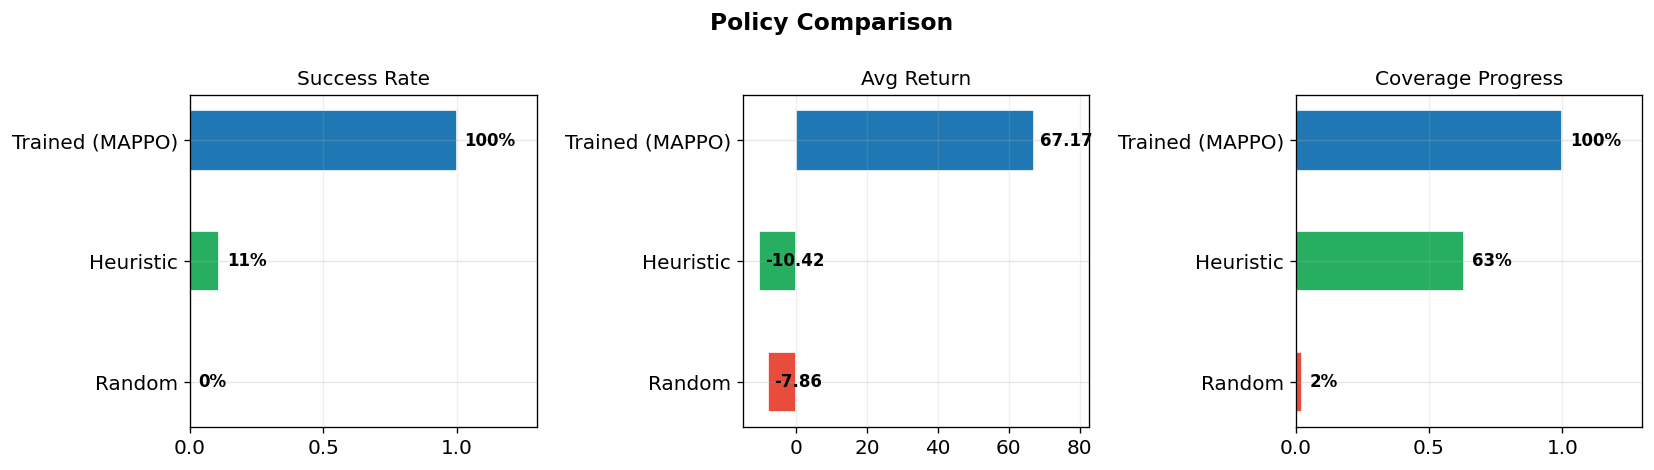

In [10]:
if not all_metrics:
    print("No completed runs yet.")
else:
    latest_run_id = sorted(all_metrics.keys())[-1]
    trained_metrics = all_metrics[latest_run_id]
    run_storage = storage.get_run(latest_run_id)

    # ── Consolidated 1x3 comparison chart ──
    comparison = {
        "Random": random_metrics,
        "Heuristic": heuristic_metrics,
        "Trained (MAPPO)": trained_metrics,
    }
    fig = plot_results_comparison(comparison)
    save_figure(fig, str(run_storage.output_dir / "results_comparison.png"))

    # ── KPI cards + inline chart ──
    display_results_dashboard(trained_metrics, comparison_fig=fig, run_id=latest_run_id)

In [11]:
if all_metrics:
    latest_run_id = sorted(all_metrics.keys())[-1]
    rs = storage.get_run(latest_run_id)
    report_path = rs.run_dir / "report.md"
    if report_path.exists():
        scrollable_md(report_path.read_text(), height=400, title="Full Run Report")

# Experiment Report: ER1 — No-Comm Control

| | |
|---|---|
| **Run ID** | `er1_mappo_n4_t7_k2_l035_s0` |
| **Folder** | `20260309_1608__er1_mappo_n4_t7_k2_l035_s0` |
| **Generated** | 2026-03-09 17:10:49 |

> Isolates baseline task difficulty by removing ALL communication. Establishes the floor that any comm method must beat. Single config run for quick validation (~15 min on CPU).

## Task Configuration (Discovery Scenario)

| Parameter | Value | Description |
|-----------|-------|-------------|
| `n_agents` (N) | **4** ⚙ | Number of agents |
| `n_targets` (T) | **7** ⚙ | Number of targets to cover |
| `agents_per_target` (K) | **2** ⚙ | Agents required per target simultaneously |
| `covering_range` | **0.25** | Distance threshold to 'cover' a target |
| `lidar_range` | **0.35** ⚙ | LiDAR sensing range |
| `targets_respawn` | **False** | Must be False for M1/M3 |
| `max_steps` | **200** | Max steps per episode |

<details><summary>Other task parameters</summary>

| Parameter | Value |
|-----------|-------|
| `use_agent_lidar` | False |
| `n_lidar_rays_entities` | 15 |
| `n_lidar_rays_agents` | 12 |
| `shared_reward` | False |
| `agent_collision_penalty` | -0.1 |
| `covering_rew_coeff` | 1.0 |
| `time_penalty` | -0.01 |
| `x_semidim` | 1.0 |
| `y_semidim` | 1.0 |
| `min_dist_between_entities` | 0.2 |

⚙ = overridden by sweep
</details>

## Training Configuration

| Setting | Value |
|---------|-------|
| Algorithm | **MAPPO** |
| Total frames | 6,000,000 |
| Iterations | 100 |
| Frames/batch | 60,000 |
| Parallel envs | 60 |
| SGD epochs/batch | 45 |
| Minibatch size | 4,096 |
| Learning rate | 5e-05 |
| Gamma | 0.99 |
| Shared policy | True |
| Device | cpu |
| Eval interval | every 600,000 frames |
| Eval episodes | 50 |

## Training Summary

- **Wall time:** 0h 59m 17s
- **Throughput:** 1,687 frames/sec
- **Time/iteration:** 35.6s

## Evaluation Results

**200 episodes** — deterministic (no exploration)

| Metric | Value | Description |
|--------|-------|-------------|
| **Success Rate** | 100.0% | Fraction of evaluation episodes where ALL targets were covered. A target is 'covered' when K agents are within covering_range simultaneously. Episode ends when every target has been covered. |
| **Avg Return** | 67.1700 | Mean cumulative reward per episode (covering + collision penalty + time penalty). Positive = covering outweighs penalties. |
| **Avg Steps to Completion** | 50.0 | Mean steps until all targets covered. Equals max_steps if episode never completes. Lower = faster. |
| **Collisions/Episode** | 362.38 | Mean agent-agent collisions per episode. |
| **Tokens/Episode** | 0.0 | Communication tokens per episode. Always 0 for no-comm baselines (ER1). |
| **Coverage Progress** | 100.0% | Fraction of targets covered by episode end (partial credit). 100% = all targets covered in every episode. |
| **Agent Utilization** | 2.000 | Coefficient of variation of per-agent covering counts. 0 = perfectly balanced workload. |
| **Spatial Spread** | 0.762 | Mean pairwise agent distance. Higher = exploring, lower = clumping. Field diagonal ≈ 2.83. |
| **Sample Efficiency** | 4,800,000 | Training frames to reach 80% of final eval reward. Lower = faster learning. |

## Output Artifacts

📁 `/Users/afin/Documents/Studio/PHD/Code/VectorizedMultiAgentSimulator/rendezvous_comm/results/er1/20260309_1608__er1_mappo_n4_t7_k2_l035_s0`

| Path | Size | Description |
|------|------|-------------|
| `input/config.yaml` | 944 B | Frozen config snapshot |
| `logs/run.log` | 1.5 KB | Training log with timestamps |
| `output/metrics.json` | 305 B | Final evaluation metrics (M1–M9) |
| `output/policy.pt` | 291.5 KB | Trained policy weights |
| `output/benchmarl/` | (dir) | BenchMARL raw outputs |

## How to Reproduce / Reload

```python
from src.runner import build_experiment
from src.storage import ExperimentStorage
storage = ExperimentStorage('er1')
run = storage.get_run('er1_mappo_n4_t7_k2_l035_s0')
state_dict = run.load_policy_state_dict()
# Rebuild experiment with same config:
experiment = build_experiment(...)
experiment.policy.load_state_dict(state_dict)
```


## Interpretation

The no-comm baseline tells us:
- **If M1 is low** (< 30%): the task is hard enough that communication should matter. Good experimental design.
- **If M1 is high** (> 60%): agents solve the task without communication — the task may be too easy, or the config too forgiving.
- **M6 vs M1 gap**: when M1 ≈ 0 but M6 > 0.5, agents learn to cover *most* targets but fail on the last few. Communication could help here.
- **M8 (utilization)**: high CV means some agents do all the work. Communication should improve coordination.
- **M9 (spread)**: low spread means agents clump. Communication can encourage exploration.

In [12]:
if all_metrics:
    df = storage.to_dataframe()
    if "n_agents" in df.columns:
        n4_df = df[df["n_agents"] == 4]
    else:
        n4_df = df

    if not n4_df.empty:
        avg_success = n4_df["M1_success_rate"].mean()
        avg_return = n4_df["M2_avg_return"].mean()
        display_verdict(avg_success, avg_return)

## Sweep Analysis

With a `sweep_*` config, we can compare success across agent counts, LiDAR ranges, and algorithms.
If you used a `single_*` config, this section will be skipped (only 1 run).

In [13]:
if all_metrics and len(all_metrics) > 1:
    df = storage.to_dataframe()
    if not df.empty:
        # Success rate heatmap across configs
        if "n_agents" in df.columns and len(df["n_agents"].unique()) > 1:
            fig = plot_sweep_heatmap(
                df, metric="M1_success_rate",
                row_param="n_agents", col_param="lidar_range",
                title="ER1: Success Rate (N agents × LiDAR range)",
            )
            save_figure(fig, str(spec.results_dir / "sweep_success_heatmap.png"))
            plt.show()

        # Algorithm comparison
        if "algorithm" in df.columns and len(df["algorithm"].unique()) > 1:
            fig = plot_seed_variance(
                df, metric="M1_success_rate", group_by="algorithm",
                title="ER1: MAPPO vs IPPO Success Rate (across seeds)",
            )
            save_figure(fig, str(spec.results_dir / "sweep_algo_comparison.png"))
            plt.show()

        display_sweep_summary(all_metrics)
else:
    print("Sweep analysis requires multiple runs. Use a sweep config and re-run.")

Sweep analysis requires multiple runs. Use a sweep config and re-run.


## Results Storage & Policy Export

Each run is self-contained in its timestamped folder:
```
results/er1/YYYYMMDD_HHMM__<run_id>/
  input/config.yaml, provenance.json
  logs/run.log
  output/metrics.json, policy.pt, *.png, benchmarl/
  report.md
```

Config files use descriptive names matching their parameters:
```
configs/er1/single_mappo_n4_l035.yaml           ← 1 run, quick validation
configs/er1/sweep_mappo-ippo_n2-6_l025-045.yaml ← full sweep
```

To reuse a trained policy, copy `policy.pt` + `config.yaml` or use `run_storage.load_policy_state_dict()`.

In [14]:
if all_metrics:
    latest_run_id = sorted(all_metrics.keys())[-1]
    run_storage = storage.get_run(latest_run_id)

    # ── Styled artifact tree ──
    display_artifact_tree(run_storage)

    # ── Policy reload example ──
    if run_storage.has_policy():
        state_dict = run_storage.load_policy_state_dict()
        if state_dict:
            total_params = sum(p.numel() for p in state_dict.values() if p is not None)
            print(f"\nPolicy: {len(state_dict)} tensors, {total_params:,} parameters")
            print(f"File:   {run_storage.output_dir / 'policy.pt'}")
else:
    print("No completed runs.")


Policy: 8 tensors, 71,941 parameters
File:   /Users/afin/Documents/Studio/PHD/Code/VectorizedMultiAgentSimulator/rendezvous_comm/results/er1/20260309_1608__er1_mappo_n4_t7_k2_l035_s0/output/policy.pt
